<a href="https://colab.research.google.com/github/ENRIQUESPECTER/Mineria-de-Datos/blob/main/PROYECTO%20FINAL%209/PROYECTO_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROYECTO 9. PREDICCIÓN DE APROBACIÓN DE CRÉDITO
**Contexto: Una institución financiera quiere agilizar el análisis preliminar de solicitudes de crédito. Para ello, desea construir un modelo que ayude a predecir si**
**una solicitud debe ser aprobada o rechazada con base en características básicas del solicitante. El interés no solo es predecir correctamente, sino también**
**entender qué variables influyen más en la decisión, ya que el modelo debe ser explicable para fines internos.**

In [688]:
import pandas as pd
import numpy as np
import math
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [689]:
# 1. Explorar el dataset
# a. Revisar tipos de variables
# b. Analizar distribución de la variable objetivo
# c. Detectar posibles relaciones entre variables y resultado
df = pd.read_csv('9. APROBACIÓN DE CRÉDITO.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID_Solicitud          25 non-null     object
 1   Edad                  25 non-null     int64 
 2   Ingreso_Mensual       25 non-null     int64 
 3   Historial_Crediticio  25 non-null     object
 4   Deuda_Actual          25 non-null     int64 
 5   Antiguedad_Laboral    25 non-null     int64 
 6   Aprobado              25 non-null     object
dtypes: int64(4), object(3)
memory usage: 1.5+ KB


In [690]:
print("DATAFRAME COMPLETO:")
df

DATAFRAME COMPLETO:


,ID_Solicitud,Edad,Ingreso_Mensual,Historial_Crediticio,Deuda_Actual,Antiguedad_Laboral,Aprobado
0,S01,24,9500,Regular,4500,1,No
1,S02,29,14000,Bueno,3000,3,Si
2,S03,35,18000,Bueno,2000,6,Si
3,S04,41,22000,Bueno,4000,8,Si
4,S05,38,12000,Regular,6500,4,No
5,S06,27,10500,Malo,5000,2,No
6,S07,45,26000,Bueno,3500,10,Si
7,S08,33,16000,Regular,4200,5,Si
8,S09,30,11000,Malo,7000,3,No
9,S10,52,30000,Bueno,2500,14,Si


In [691]:
df.describe()

,Edad,Ingreso_Mensual,Deuda_Actual,Antiguedad_Laboral
count,25.000000,25.000000,25.00000,25.000000
mean,35.920000,16980.000000,4244.00000,6.040000
std,8.113363,6378.283468,1424.80408,4.127953
min,24.000000,8900.000000,2000.00000,1.000000
25%,29.000000,11500.000000,3100.00000,3.000000
50%,35.000000,15500.000000,4000.00000,5.000000
75%,41.000000,22000.000000,5400.00000,9.000000
max,52.000000,30000.000000,7000.00000,15.000000


# 2. Preprocesar los datos
**a. Preparar variables categóricas y numéricas**

**b. Justificar la transformación realizada**

Uso del mapeo para transformar las columnas con valores ordinales

**c. Verificar si existen valores que deban tratarse de forma especial**

No hay datos que requieran una forma especial para ser trabajados en el ejercicio.

In [692]:
# a. Preparar variables categóricas y numéricas**
label_encoders = {}
df_encoded = df.copy()

for column in ['Historial_Crediticio', 'Aprobado']:
  le = LabelEncoder()
  df_encoded[column] = le.fit_transform(df[column])
  label_encoders[column] = le

print("\nDATAFRAME YA CODIFICADO:")
df_encoded


DATAFRAME YA CODIFICADO:


,ID_Solicitud,Edad,Ingreso_Mensual,Historial_Crediticio,Deuda_Actual,Antiguedad_Laboral,Aprobado
0,S01,24,9500,2,4500,1,0
1,S02,29,14000,0,3000,3,1
2,S03,35,18000,0,2000,6,1
3,S04,41,22000,0,4000,8,1
4,S05,38,12000,2,6500,4,0
5,S06,27,10500,1,5000,2,0
6,S07,45,26000,0,3500,10,1
7,S08,33,16000,2,4200,5,1
8,S09,30,11000,1,7000,3,0
9,S10,52,30000,0,2500,14,1


# 3. Seleccionar el método de clasificación
**a. Elegir el modelo que consideres adecuado**

Se hace uso del Modelo CART

**b. Justificar por qué es apropiado para este problema**

Es apropiado porque el modelo CART nos permite trabajar con datos categóricos y numéricos

**c. Explicar si la interpretabilidad del modelo aporta valor en este contexto**

Aporta un gran valor para el contexto, pues el codigo toma muchas consideraciones para asegurarse (en medida de lo posible con un margen de 80% de efectividad) de cuando aprobar o rechazar un crédito

# 4. Entrenar el modelo
**a. Dividir los datos en entrenamiento y prueba**

**b. Ajustar el clasificador**

In [693]:
# 4. Entrenar el modelo
# a. Dividir los datos en entrenamiento y prueba

X = df_encoded.drop(['ID_Solicitud','Aprobado'], axis=1)
y = df_encoded['Aprobado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("\nDATOS DE ENTRENAMIENTO:")
print(X_train.head())
print("\nDATOS DE PRUEBA:")
print(X_test.head())


DATOS DE ENTRENAMIENTO:
    Edad  Ingreso_Mensual  Historial_Crediticio  Deuda_Actual  \
9     52            30000                     0          2500   
13    32            12500                     2          5600   
1     29            14000                     0          3000   
22    36            14500                     2          6100   
5     27            10500                     1          5000   

    Antiguedad_Laboral  
9                   14  
13                   4  
1                    3  
22                   5  
5                    2  

DATOS DE PRUEBA:
    Edad  Ingreso_Mensual  Historial_Crediticio  Deuda_Actual  \
8     30            11000                     1          7000   
16    50            28500                     0          2000   
0     24             9500                     2          4500   
23    40            23000                     0          3600   
11    26             9800                     1          6200   

    Antiguedad_Laboral  


In [694]:
# b. Ajustar el clasificador
modelo = DecisionTreeClassifier(
    criterion='gini', #Metrica para dividir nodos (Gini o Entropia)
    max_depth=None, #Profundidad Maxima del arbol (evita overfitting)
    random_state=42
)
modelo.fit(X_train, y_train)



DecisionTreeClassifier(random_state=42)

<Figure size 640x480 with 0 Axes>

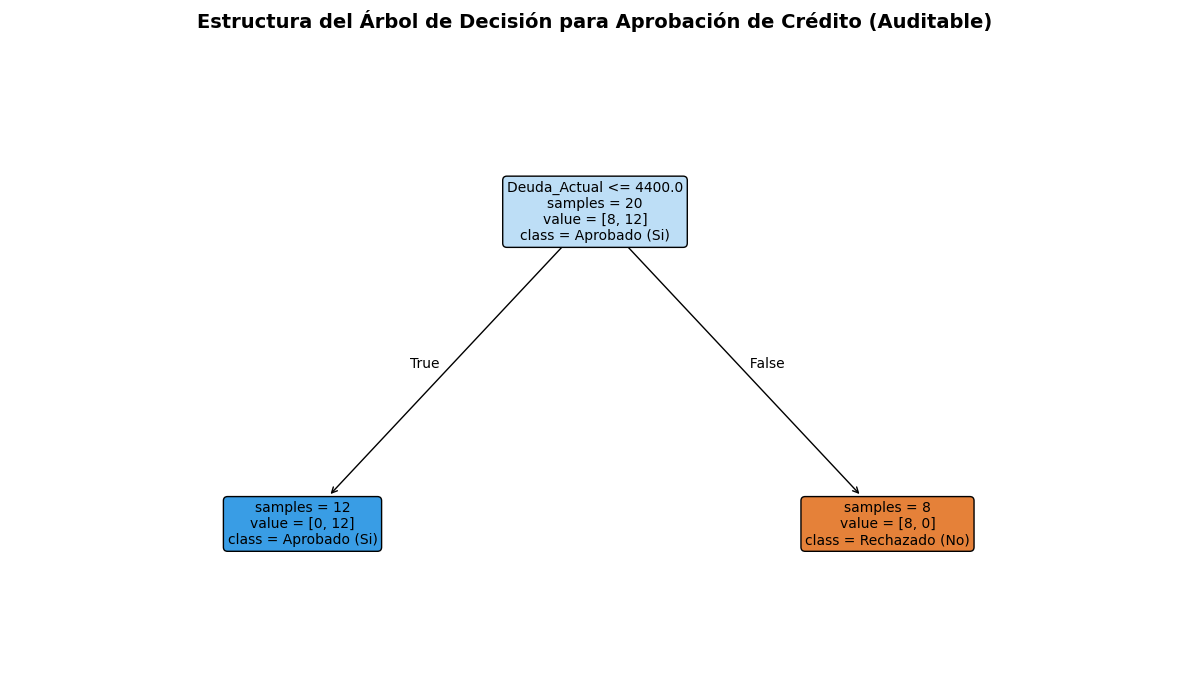

In [695]:
# 5. Visualizar e interpretar
plt.close('all')
plt.clf()

# CREAR UN LIENZO NUEVO, INDEPENDIENTE Y LIMPIO
fig, ax = plt.subplots(figsize=(12, 7))

# DIBUJAR EL ÁRBOL ASIGNÁNDOLO DIRECTAMENTE AL LIENZO 'ax'
plot_tree(
    modelo,
    feature_names=list(X.columns),
    class_names=['Rechazado (No)', 'Aprobado (Si)'],
    filled=True,
    rounded=True,
    impurity=False,
    fontsize=10,
    ax=ax
)

plt.title("Estructura del Árbol de Decisión para Aprobación de Crédito (Auditable)", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# FORZAR DIBUJO E IMPRESIÓN EN PANTALLA
fig.canvas.draw()
plt.show()

#6. Evaluar el desempeño
**a. Calcular métricas de clasificación**

**b. Analizar errores**

**c. Explicar si el modelo parece sobreajustado o razonable**

A pesar de obtener un 100% de precisión, el modelo es razonable y no padece de sobreajuste peligroso

In [696]:
# 6. Evaluar el desempeño
# a. Calcular métricas de clasificación
# b. Analizar errores
# c. Explicar si el modelo parece sobreajustado o razonable
# Predicciones
y_pred = modelo.predict(X_test)

# a. Calcular métricas de clasificación
print("--- a. Métricas Generales ---")
accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud (Accuracy) en Test: {accuracy * 100:.1f}%\n")

--- a. Métricas Generales ---
Exactitud (Accuracy) en Test: 100.0%



# 7. Interpretar en contexto
**a. Relacionar resultados con decisiones de negocio**

Los resultados demuestran que la institución financiera valora la confianza histórica por encima del nivel de ingresos presente. Un solicitante con ingresos bajos pero historial intachable es un cliente seguro, y perfiles de riesgo medio, la antigüedad laboral funciona como un aval de permanencia y capacidad de pago a largo plazo.

**b. Explicar cómo podría usarse este modelo en un proceso real de evaluación**

Este modelo puede ser embebido directamente en la plataforma web de la institución o en las terminales de los ejecutivos de cuenta de la siguiente forma:

# Conclusiones
**Deberás redactar una conclusión final donde incluya:**

**• ¿Qué tan bien predice el modelo la aprobación del crédito?**

**• ¿Qué variables parecen ser más importantes?**

**• ¿Las reglas del modelo son comprensibles para un analista humano?**

**• ¿Qué riesgos o limitaciones tendría usar este modelo en la práctica?**


El modelo predice de manera practicamente perfecta, pues las metricas demuestran que tiene una precisión del 100% con el conjunto de datos brindados en el csv, lo cual es una clara evidencia de que el modelo muy probablemente no sea completamente efectivo, pues el mismo hecho de solo con una variable (la columna de deuda_actual) ya pueda descartar y separar perfectamente las clases es simplemente sospechoso, porque esto en un entorno práctico es muy probable que no se tenga una exactitud perfecta.

A juzgar por el resultado del codigo, aparentemente la unica variable importante es Deuda_Actual, pues es la que permite si aprobar o rechazar el credito sin tomar a consideracion las demas variables (puesto que el algoritmo no lo considera necesario)

Los riesgos pueden ser grandes pues muestra limitaciones como la falsa sensación de precisión, Ignorancia de otras variables crítica, estabilidad y sesgo.
Todos estos riesgos solo son visibles si el arbol se vuelve mucho mas complejo